# 日文新闻主题聚类

使用字符 TF-IDF、TruncatedSVD 和 MiniBatchKMeans 对 Livedoor 新闻进行无监督聚类。编辑栏目标签只用于聚类完成后的外部评价。

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from news_clustering import *
sns.set_theme(style="whitegrid")

## 1. 数据概览

In [2]:
data = load_articles(ensure_data(PROJECT_ROOT / "data"))
pd.DataFrame(
    {
        "文章数": [len(data)],
        "编辑栏目数": [data.category.nunique()],
        "标题平均长度": [data.title.str.len().mean()],
    }
).round(1)

,文章数,编辑栏目数,标题平均长度
0,7367,9,37.7


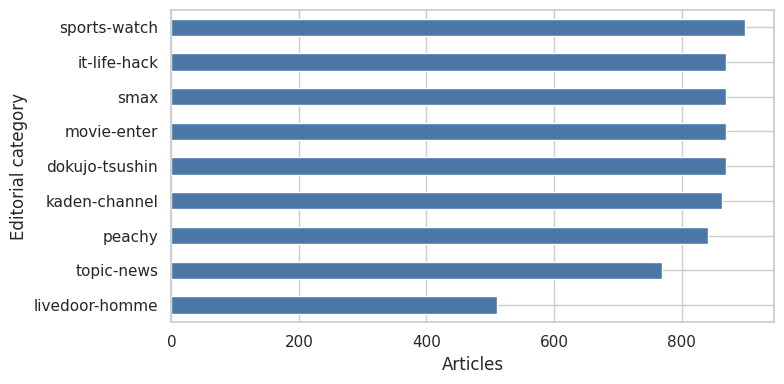

In [3]:
data.groupby("category").size().sort_values().plot.barh(figsize=(8, 4), color="#4c78a8")
plt.xlabel("Articles")
plt.ylabel("Editorial category")
plt.tight_layout()
plt.show()

## 2. 文本表示与无监督选簇

In [4]:
representation = Pipeline(
    [
        ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(2, 4), min_df=3, max_df=.95, sublinear_tf=True, max_features=80000)),
        ("svd", TruncatedSVD(n_components=100, random_state=SEED)),
        ("normalize", Normalizer(copy=False)),
    ]
)
documents = data.title + " " + data.content.str.slice(0, 1000)
embedding = representation.fit_transform(documents)
k_table = select_k(embedding, [6, 7, 8, 9, 10, 11, 12])
k_table.round(3)

,k,silhouette
0,6,0.107
1,7,0.159
2,8,0.156
3,9,0.162
4,10,0.158
5,11,0.157
6,12,0.168


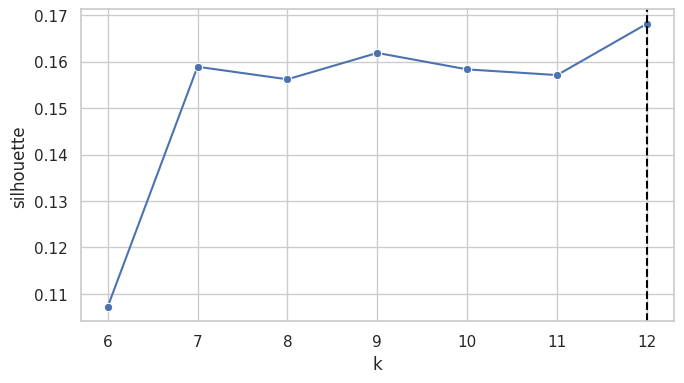

In [5]:
best_k = int(k_table.loc[k_table.silhouette.idxmax(), "k"])
plt.figure(figsize=(7, 4))
sns.lineplot(data=k_table, x="k", y="silhouette", marker="o")
plt.axvline(best_k, color="black", linestyle="--")
plt.tight_layout()
plt.show()

## 3. 最终聚类与代表标题

In [6]:
model = MiniBatchKMeans(n_clusters=best_k, n_init=30, batch_size=512, random_state=SEED).fit(embedding)
metrics = {
    "Silhouette": k_table.silhouette.max(),
    "ARI": adjusted_rand_score(data.category, model.labels_),
    "NMI": normalized_mutual_info_score(data.category, model.labels_),
}
pd.DataFrame([metrics]).round(3)

,Silhouette,ARI,NMI
0,0.168,0.542,0.637


In [7]:
summary = representative_titles(data, embedding, model)
summary

,cluster,size,representative_titles
3,3,1143,コンプレックスを自信に変える女たち | 「整形したい」女性が大半。コンプレックスを感じる顔の...
7,7,961,わずか7.8mmのボディに全部入り！スタイリッシュスマートフォン「MEDIAS X N-07...
9,9,858,志村けん、全米で大ヒット中の映画で声優に初挑戦 | 謎の人体発火、ウルフドッグによる連続殺人...
0,0,804,LANだけで動作するコンピュータ 電源不要のオールインワン型【デジ通】 | まだまだ残暑厳し...
2,2,730,日本最大級のロクシタンが上野にオープン！ 超お得な限定セットも | 99.5%が“プロの味”...
4,4,728,あまりにも多すぎる「会いたくて」への皮肉か!? 「西野カナゲーム」が流行 | 「ザスパ草津」...
1,1,690,【Sports Watch】石井慧、女子大生との電撃婚も新婚の実態は？ | 【Sports ...
8,8,575,今度の貞子はネットを使って呪いを拡散？ 「リング」シリーズ最新作の構想が明らかに【話題】 |...
5,5,392,蓮舫氏、退任となった最大の理由は“不倫疑惑”か | 「今は無事だが原発事故が東京に20年後影...
10,10,305,「スッキリ!!」で映った箱根駅伝出場選手の部屋が話題に | 「視聴者ナメてんの？」 NHKの...


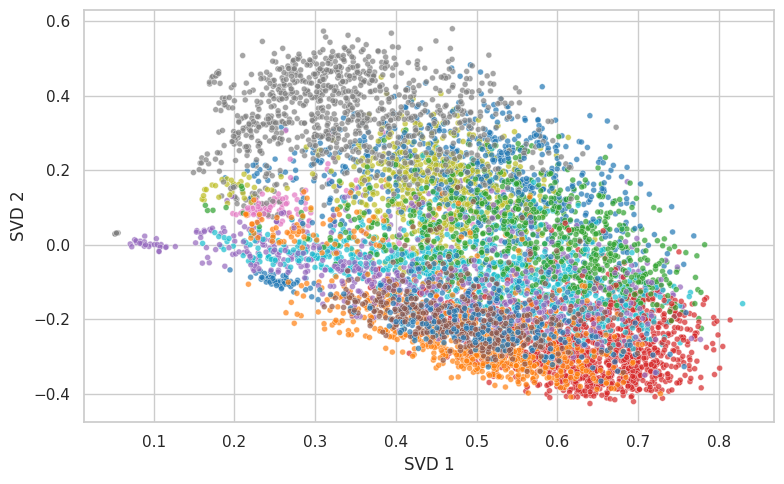

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=model.labels_, palette="tab10", s=18, alpha=.7, legend=False)
plt.xlabel("SVD 1")
plt.ylabel("SVD 2")
plt.tight_layout()
plt.show()

## 结论

- 无监督方法选择了 12 个簇，轮廓系数约为 **0.168**。
- 聚类与九个编辑栏目的 ARI 约为 **0.542**、NMI 约为 **0.637**。
- 代表标题表明，模型识别出了体育、电影、Android、科技和女性生活等主题。
- 二维投影只用于展示；聚类实际在归一化后的 100 维空间中完成。